In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="white",
    context="talk",
    palette="Set2")


In [ ]:
df = pd.read_csv("Sales_Cleaned.csv")

In [94]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Month Name,Year_Month,Customer_Type
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,September,2023-09,Low Value
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,2023,5,May,2023-05,High Value
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,2023,7,July,2023-07,Low Value
3,TXN_7034554,Salad,2.0,5.0,10.0,UPI Payment,Online / Unspecified,2023-04-27,2023,4,April,2023-04,Medium Value
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023,6,June,2023-06,Low Value
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9422,TXN_7851634,Sandwich,4.0,4.0,16.0,UPI Payment,Online / Unspecified,2023-01-08,2023,1,January,2023-01,High Value
9423,TXN_7672686,Coffee,2.0,2.0,4.0,UPI Payment,Online / Unspecified,2023-08-30,2023,8,August,2023-08,Low Value
9424,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Online / Unspecified,2023-03-02,2023,3,March,2023-03,Medium Value
9425,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,Online / Unspecified,2023-12-02,2023,12,December,2023-12,Low Value


In [ ]:
df.head()
df.info()
df.describe()

In [ ]:
#Sales Performance Analysis
#Total Sales
total_sales = df["Total Spent"].sum()
total_sales

In [ ]:
#Average Transaction Value
avg_transaction = df["Total Spent"].mean()
avg_transaction

In [ ]:
#Total Quantity Sold
total_quantity = df["Quantity"].sum()
total_quantity

In [ ]:
#Item-wise Analysis
#Top 10 Best-Selling Items (Revenue)
item_sales = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False).reset_index()
item_sales.head(10)

In [ ]:
# Most Sold Items (Quantity)
item_quantity = df.groupby("Item")["Quantity"].sum().sort_values(ascending=False).reset_index()
item_quantity.head(10)

In [ ]:
# Payment Method Analysis
payment_sales = df.groupby("Payment Method")["Total Spent"].sum().reset_index()
payment_sales

In [20]:
item_revenue = (
    df.groupby("Item")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

item_revenue["Revenue_Contribution_%"] = (
    item_revenue["Total Spent"] / total_sales
) * 100

item_revenue


,Item,Total Spent,Revenue_Contribution_%
0,Salad,18210.0,21.625024
1,Sandwich,15608.0,18.535056
2,Smoothie,12784.0,15.181455
3,Cake,11841.0,14.061609
4,Juice,10032.0,11.913357
5,Coffee,7490.0,8.894642
6,Tea,4366.5,5.185374
7,Cookie,3416.0,4.056622
8,Unknown Item,460.5,0.546860


In [21]:
payment_sales = (
    df.groupby("Payment Method")["Total Spent"]
    .sum()
    .reset_index()
    .sort_values("Total Spent", ascending=False))
payment_sales

,Payment Method,Total Spent
3,UPI Payment,26069.5
2,Digital Wallet,19451.0
0,Cash,19398.0
1,Credit Card,19289.5


In [22]:
payment_count = df["Payment Method"].value_counts().reset_index()
payment_count

,Payment Method,count
0,UPI Payment,2974
1,Digital Wallet,2178
2,Credit Card,2139
3,Cash,2136


In [23]:
#Payment Method – Behavioral Analysis
#Revenue vs Count
payment_summary = df.groupby("Payment Method").agg(
    Total_Revenue=("Total Spent", "sum"),
    Transactions=("Total Spent", "count"),
    Avg_Bill_Value=("Total Spent", "mean")).reset_index()

payment_summary

,Payment Method,Total_Revenue,Transactions,Avg_Bill_Value
0,Cash,19398.0,2136,9.081461
1,Credit Card,19289.5,2139,9.017999
2,Digital Wallet,19451.0,2178,8.930670
3,UPI Payment,26069.5,2974,8.765804


In [24]:
#Location-wise Analysis
# Sales by Location
location_sales = df.groupby("Location")["Total Spent"].sum().sort_values(ascending=False).reset_index()
location_sales

,Location,Total Spent
0,Online / Unspecified,33365.0
1,In-store,25655.5
2,Takeaway,25187.5


In [25]:
#Average Bill Value by Location
df.groupby("Location")["Total Spent"].mean().sort_values(ascending=False).reset_index()

,Location,Total Spent
0,In-store,9.046368
1,Online / Unspecified,8.942643
2,Takeaway,8.806818


In [26]:
#Location-Level Advanced Analysis
# Location Performance Matrix
location_summary = df.groupby("Location").agg(
    Total_Revenue=("Total Spent", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Avg_Bill_Value=("Total Spent", "mean"),
    Transactions=("Total Spent", "count")
).sort_values("Total_Revenue", ascending=False)

location_summary

,Total_Revenue,Total_Quantity,Avg_Bill_Value,Transactions
Location,,,,
Online / Unspecified,33365.0,11187.0,8.942643,3731
In-store,25655.5,8586.0,9.046368,2836
Takeaway,25187.5,8637.0,8.806818,2860


In [18]:
location_summary["Revenue_per_Transaction"] = (
    location_summary["Total_Revenue"] /
    location_summary["Transactions"]
)
location_summary

,Total_Revenue,Total_Quantity,Avg_Bill_Value,Transactions,Revenue_per_Transaction
Location,,,,,
Online / Unspecified,33365.0,11187.0,8.942643,3731,8.942643
In-store,25655.5,8586.0,9.046368,2836,9.046368
Takeaway,25187.5,8637.0,8.806818,2860,8.806818


In [29]:
#Time-Series Analysis
# Monthly Growth Rate
monthly_sales["Growth_Rate_%"] = monthly_sales["Total Spent"].pct_change() * 100
monthly_sales

,Year,Month,Total Spent,Growth_Rate_%
0,2023,1,7224.0,NaN
1,2023,2,6578.0,-8.942414
2,2023,3,7141.0,8.558832
3,2023,4,7160.0,0.266069
4,2023,5,6871.0,-4.036313
5,2023,6,7306.0,6.330956
6,2023,7,6806.0,-6.843690
7,2023,8,7059.0,3.717308
8,2023,9,6842.0,-3.074090
9,2023,10,7217.5,5.488161


In [28]:
monthly_sales = (
    df.groupby(["Year", "Month"])["Total Spent"]
    .sum()
    .reset_index()
)
monthly_sales


,Year,Month,Total Spent
0,2023,1,7224.0
1,2023,2,6578.0
2,2023,3,7141.0
3,2023,4,7160.0
4,2023,5,6871.0
5,2023,6,7306.0
6,2023,7,6806.0
7,2023,8,7059.0
8,2023,9,6842.0
9,2023,10,7217.5


In [30]:
#Year-on-Year Comparison
yearly_sales = df.groupby("Year")["Total Spent"].sum().reset_index()
yearly_sales

,Year,Total Spent
0,2023,84208.0


In [35]:
#Month-wise Sales (Seasonality)
#Seasonality Strength Analysis
monthly_sales["Contribution_%"] = (monthly_sales["Total Spent"] / total_sales) * 100
monthly_sales

,Year,Month,Total Spent,Growth_Rate_%,Contribution_%
0,2023,1,7224.0,NaN,8.578757
1,2023,2,6578.0,-8.942414,7.811609
2,2023,3,7141.0,8.558832,8.480192
3,2023,4,7160.0,0.266069,8.502755
4,2023,5,6871.0,-4.036313,8.159557
5,2023,6,7306.0,6.330956,8.676135
6,2023,7,6806.0,-6.843690,8.082367
7,2023,8,7059.0,3.717308,8.382814
8,2023,9,6842.0,-3.074090,8.125119
9,2023,10,7217.5,5.488161,8.571038


In [32]:
#Price & Quantity Relationship
df[["Quantity", "Price Per Unit", "Total Spent"]].corr()

,Quantity,Price Per Unit,Total Spent
Quantity,1.000000,0.008861,0.707512
Price Per Unit,0.008861,1.000000,0.644435
Total Spent,0.707512,0.644435,1.000000


<Axes: xlabel='Quantity', ylabel='Total Spent'>

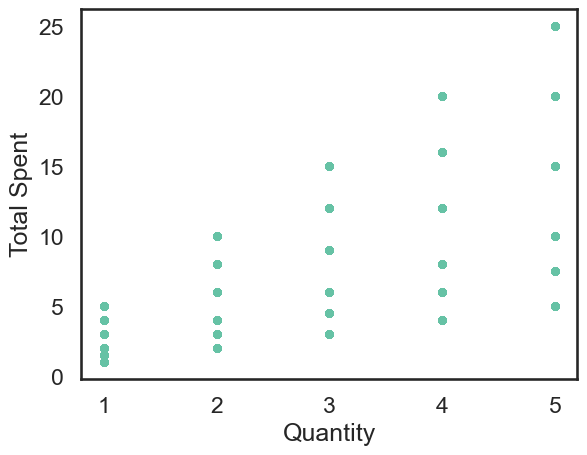

In [33]:
df.plot.scatter(x="Quantity", y="Total Spent")

In [38]:
# Outlier Contribution to Revenue
outlier_revenue = outliers["Total Spent"].sum()
(outlier_revenue / total_sales) * 100

np.float64(7.6892931787953644)

In [37]:
#Outlier Detection (Total Spent)
Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Total Spent"] < lower_bound) | (df["Total Spent"] > upper_bound)]
outliers

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Month Name,Year_Month
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,2023,11,November,2023-11
48,TXN_6342161,Salad,5.0,5.0,25.0,UPI Payment,Takeaway,2023-01-08,2023,1,January,2023-01
49,TXN_8914892,Salad,5.0,5.0,25.0,Digital Wallet,Online / Unspecified,2023-03-15,2023,3,March,2023-03
91,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-store,2023-06-10,2023,6,June,2023-06
95,TXN_9517146,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-10-30,2023,10,October,2023-10
...,...,...,...,...,...,...,...,...,...,...,...,...
9233,TXN_1232346,Salad,5.0,5.0,25.0,Digital Wallet,In-store,2023-01-04,2023,1,January,2023-01
9247,TXN_9506076,Salad,5.0,5.0,25.0,UPI Payment,Online / Unspecified,2023-01-17,2023,1,January,2023-01
9316,TXN_6393305,Salad,5.0,5.0,25.0,Digital Wallet,In-store,2023-10-19,2023,10,October,2023-10
9343,TXN_8922585,Salad,5.0,5.0,25.0,Credit Card,Online / Unspecified,2023-06-22,2023,6,June,2023-06


In [39]:
#Customer Segmentation (Value-Based)
df["Customer_Type"] = pd.qcut(
    df["Total Spent"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

df["Customer_Type"].value_counts().reset_index()

,Customer_Type,count
0,Low Value,3463
1,High Value,3100
2,Medium Value,2864


In [40]:
#Pareto Analysis (80–20 Rule)
item_revenue["Cumulative_%"] = item_revenue["Revenue_Contribution_%"].cumsum()

item_revenue[item_revenue["Cumulative_%"] <= 80]

#📌 Insight:
#A small % of items generate ~80% of revenue.

,Item,Total Spent,Revenue_Contribution_%,Cumulative_%
0,Salad,18210.0,21.625024,21.625024
1,Sandwich,15608.0,18.535056,40.160080
2,Smoothie,12784.0,15.181455,55.341535
3,Cake,11841.0,14.061609,69.403145


In [41]:
# High-Value Customer Contribution
df.groupby("Customer_Type")["Total Spent"].sum().reset_index()

C:\Users\aditya\AppData\Local\Temp\ipykernel_8216\4191937306.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Customer_Type")["Total Spent"].sum().reset_index()


,Customer_Type,Total Spent
0,Low Value,11335.5
1,Medium Value,22426.5
2,High Value,50446.0


In [42]:
# Location Quality vs Quantity
location_summary[["Avg_Bill_Value", "Total_Quantity"]]

,Avg_Bill_Value,Total_Quantity
Location,,
Online / Unspecified,8.942643,11187.0
In-store,9.046368,8586.0
Takeaway,8.806818,8637.0


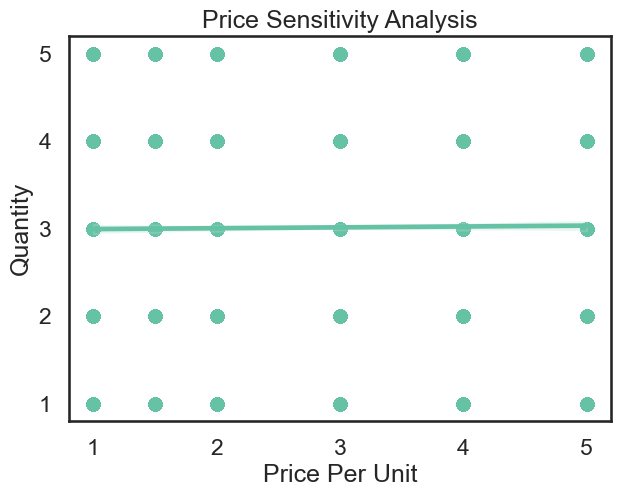

In [44]:
# Price Sensitivity (ADVANCED)
plt.figure(figsize=(7,5))
sns.regplot(
    data=df,
    x="Price Per Unit",
    y="Quantity",
    scatter_kws={"alpha":0.5}
)
plt.title("Price Sensitivity Analysis")
plt.show()

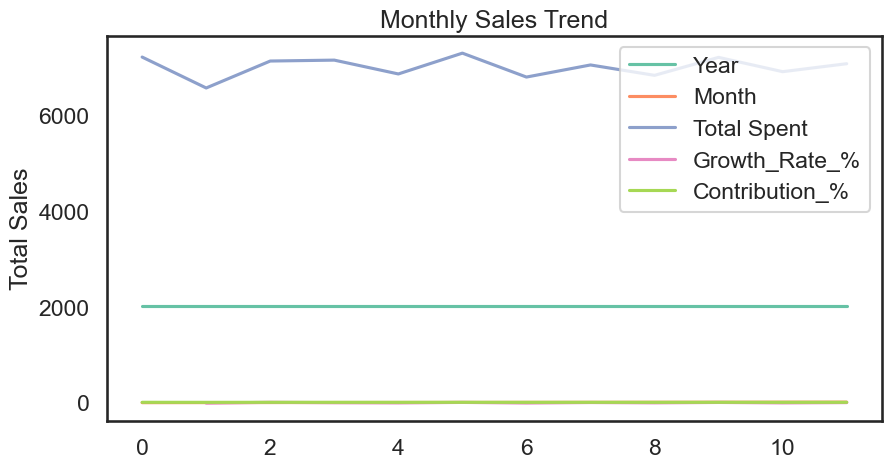

In [45]:
# Monthly Sales Trend
monthly_sales.plot(kind="line", title="Monthly Sales Trend", figsize=(10,5))
plt.ylabel("Total Sales")
plt.show()

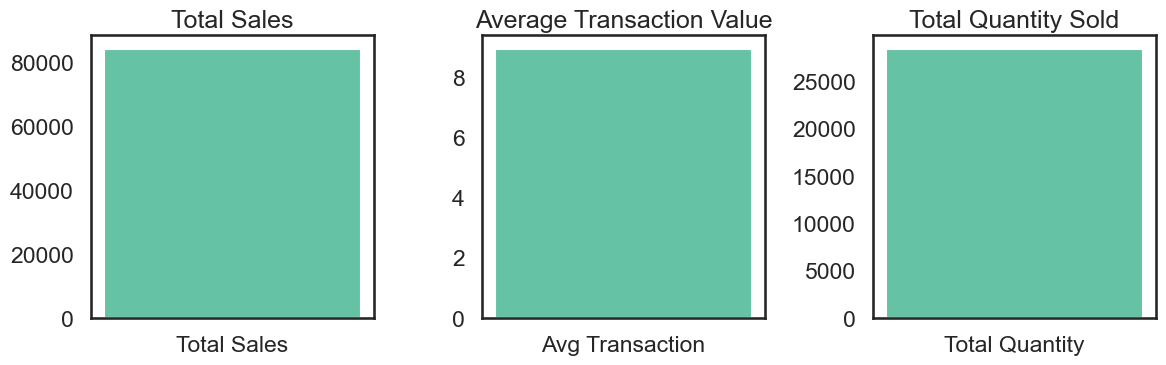

In [67]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.bar(["Total Sales"], [total_sales])
plt.title("Total Sales")

plt.subplot(1,3,2)
plt.bar(["Avg Transaction"], [avg_transaction])
plt.title("Average Transaction Value")

plt.subplot(1,3,3)
plt.bar(["Total Quantity"], [total_quantity])
plt.title("Total Quantity Sold")

plt.tight_layout()
plt.show()


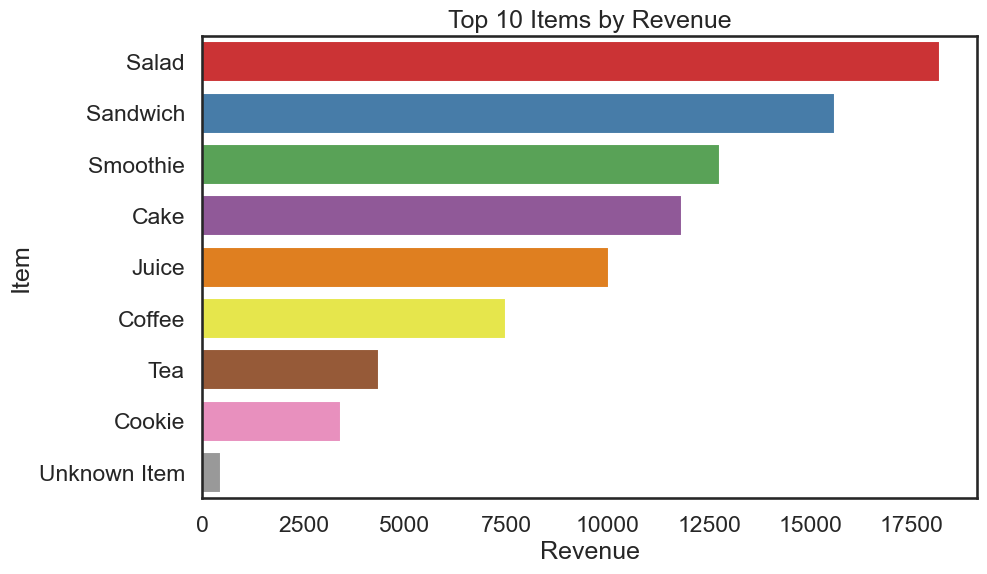

In [69]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=item_sales.head(10),
    x="Total Spent",
    y="Item",
    hue="Item",
    palette="Set1"
)
plt.title("Top 10 Items by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Item")
plt.show()


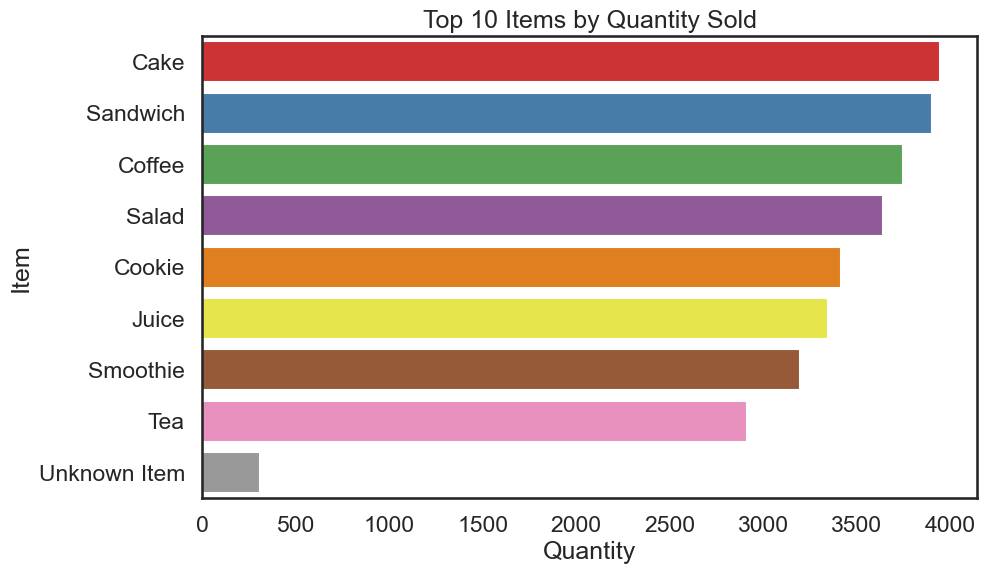

In [72]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=item_quantity.head(10),
    x="Quantity",
    y="Item",
    hue="Item",
    palette="Set1"
)
plt.title("Top 10 Items by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Item")
plt.show()


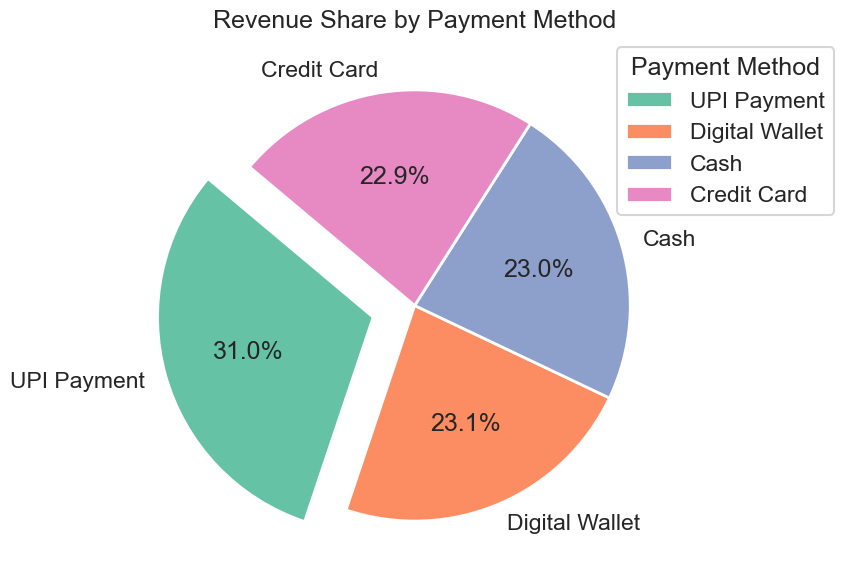

In [79]:
m=[0.2,0,0,0]

plt.figure(figsize=(7,7))
plt.pie(
    payment_sales["Total Spent"],
    labels=payment_sales["Payment Method"],
    autopct="%1.1f%%",
    startangle=140,
    explode=m,
    wedgeprops={"edgecolor":"white","linewidth":2}
)
plt.title("Revenue Share by Payment Method")
plt.legend(title="Payment Method",loc="upper right",bbox_to_anchor=(1.3,1))
plt.show()


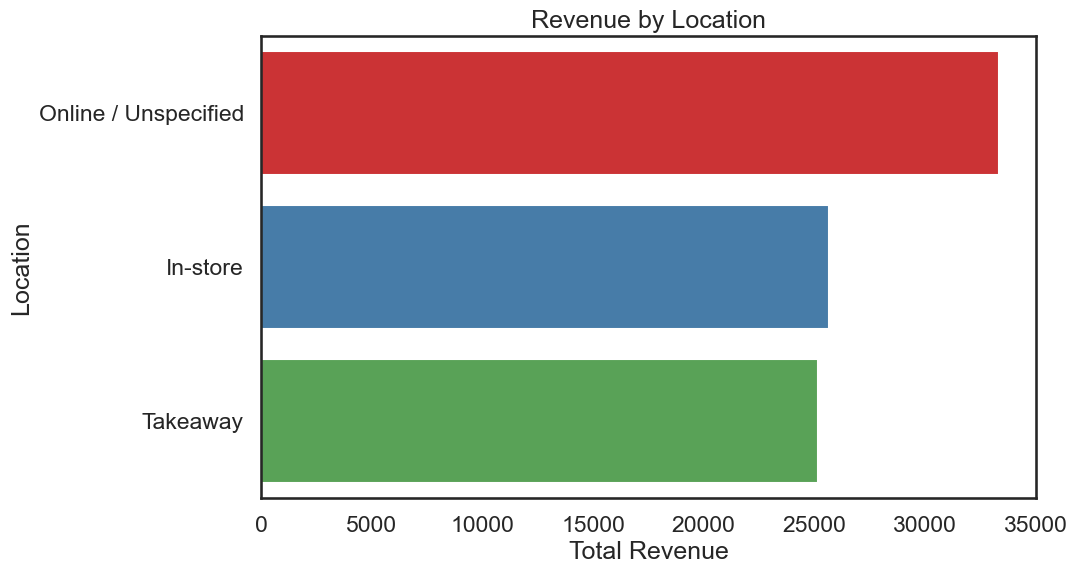

In [81]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=location_sales,
    x="Total Spent",
    y="Location",
    hue="Location",
    palette="Set1"
)
plt.title("Revenue by Location")
plt.xlabel("Total Revenue")
plt.ylabel("Location")
plt.show()


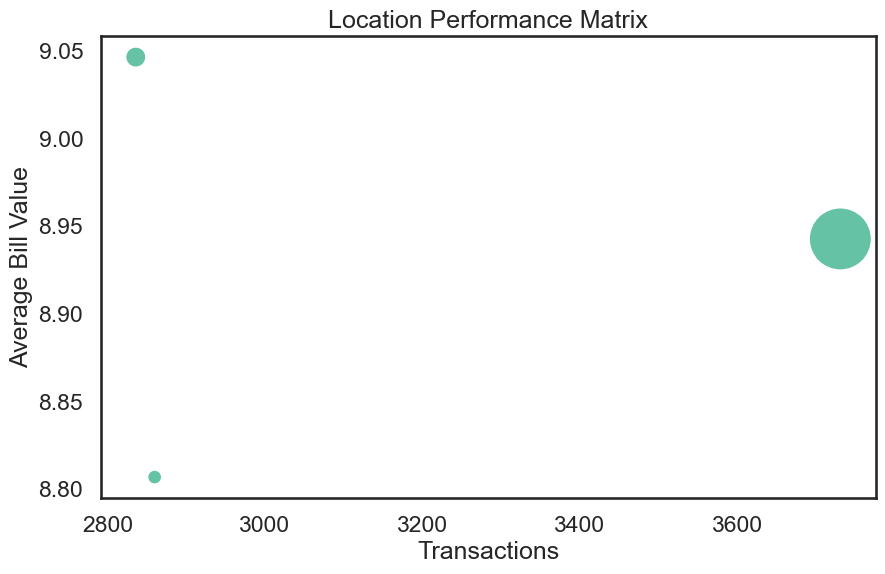

In [51]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=location_summary.reset_index(),
    x="Transactions",
    y="Avg_Bill_Value",
    size="Total_Revenue",
    sizes=(100, 2000),
    legend=False
)
plt.title("Location Performance Matrix")
plt.xlabel("Transactions")
plt.ylabel("Average Bill Value")
plt.show()


In [ ]:
#📌 Interpretation

#Top-right → Best locations

#Bottom-right → Premium but low volume

#Top-left → High volume, low value

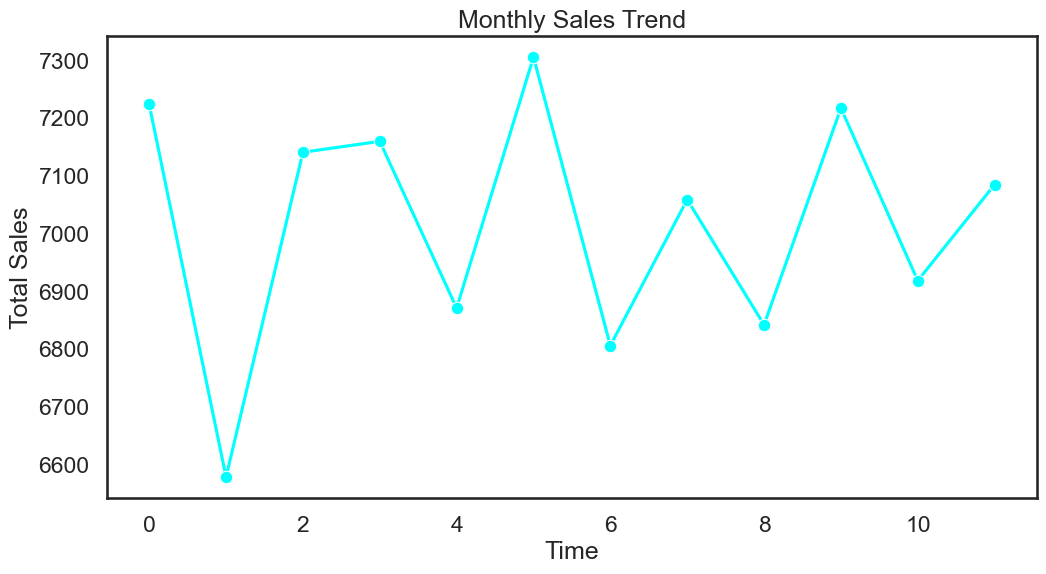

In [87]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_sales,
    x=monthly_sales.index,
    y="Total Spent",
    color="cyan",
    marker="o"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Time")
plt.ylabel("Total Sales")
plt.show()


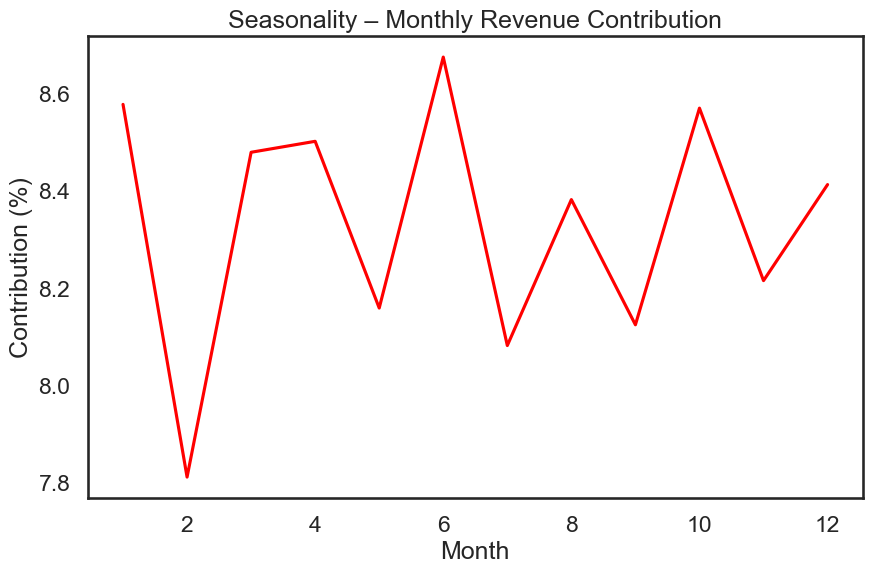

In [89]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Contribution_%",
    color="red"
)
plt.title("Seasonality – Monthly Revenue Contribution")
plt.ylabel("Contribution (%)")
plt.show()


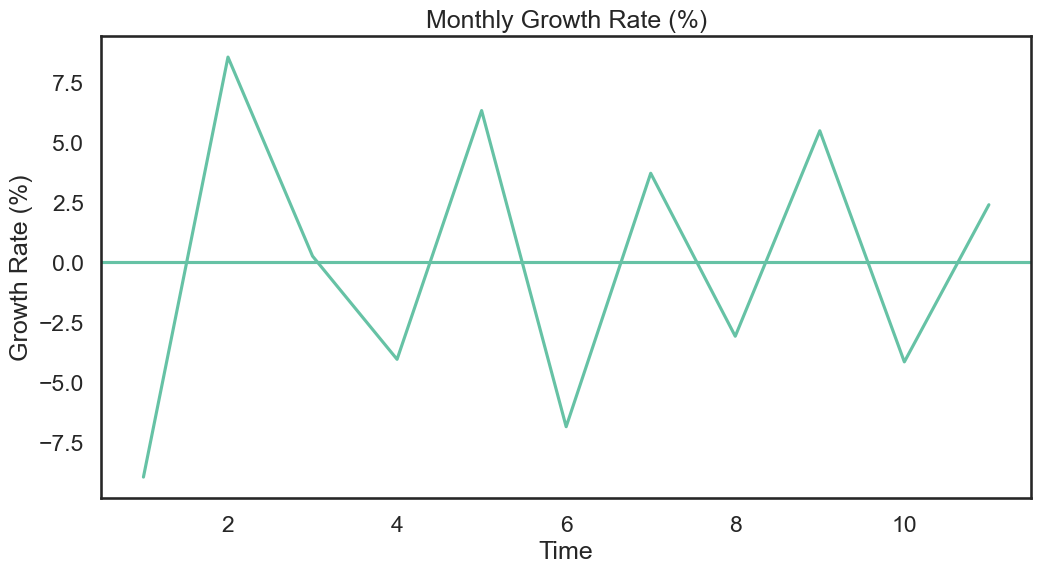

In [59]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_sales,
    x=monthly_sales.index,
    y="Growth_Rate_%"
)
plt.axhline(0)
plt.title("Monthly Growth Rate (%)")
plt.xlabel("Time")
plt.ylabel("Growth Rate (%)")
plt.show()


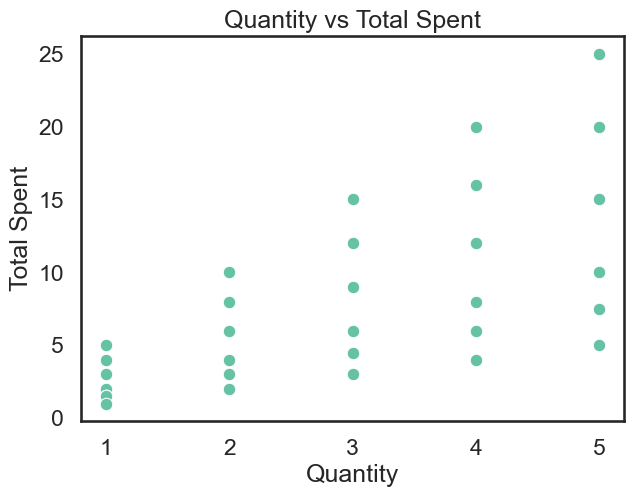

In [60]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total Spent"
)
plt.title("Quantity vs Total Spent")
plt.show()


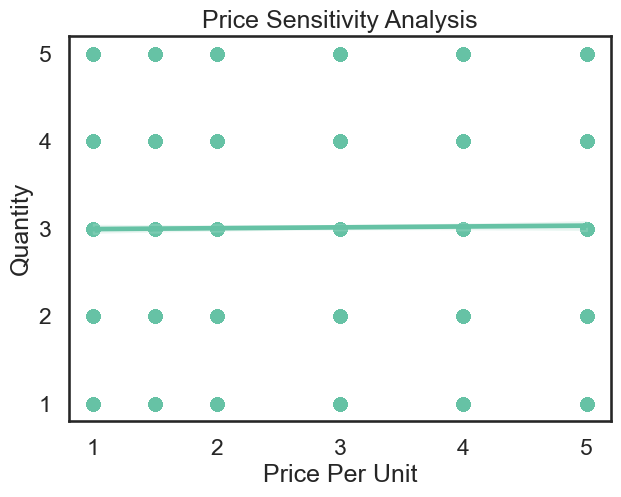

In [61]:
plt.figure(figsize=(7,5))
sns.regplot(
    data=df,
    x="Price Per Unit",
    y="Quantity",
    scatter_kws={"alpha":0.5}
)
plt.title("Price Sensitivity Analysis")
plt.show()


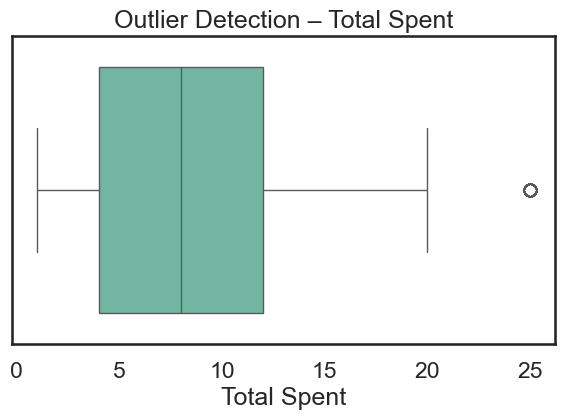

In [62]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["Total Spent"])
plt.title("Outlier Detection – Total Spent")
plt.show()


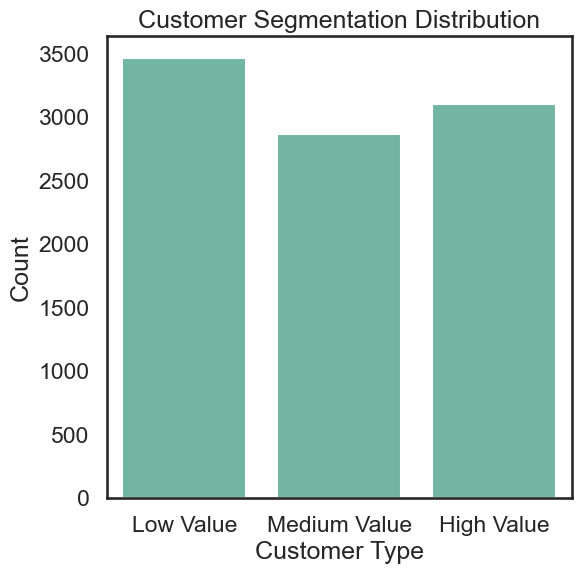

In [63]:
plt.figure(figsize=(6,6))
sns.countplot(
    data=df,
    x="Customer_Type"
)
plt.title("Customer Segmentation Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Count")
plt.show()


C:\Users\aditya\AppData\Local\Temp\ipykernel_8216\103350850.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data=df.groupby("Customer_Type")["Total Spent"].sum().reset_index(),


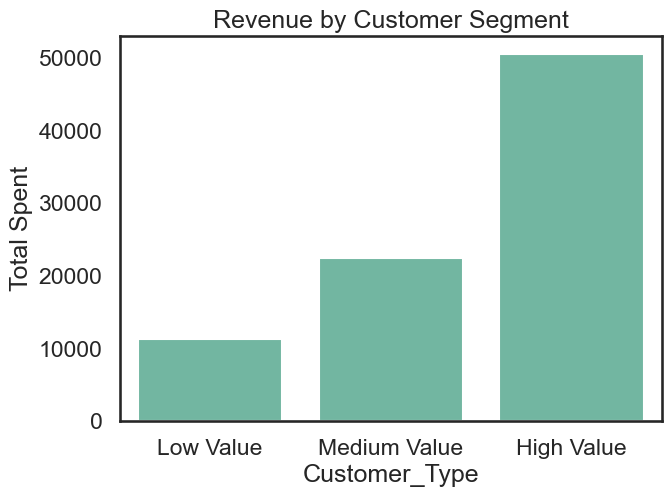

In [64]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=df.groupby("Customer_Type")["Total Spent"].sum().reset_index(),
    x="Customer_Type",
    y="Total Spent"
)
plt.title("Revenue by Customer Segment")
plt.show()
,

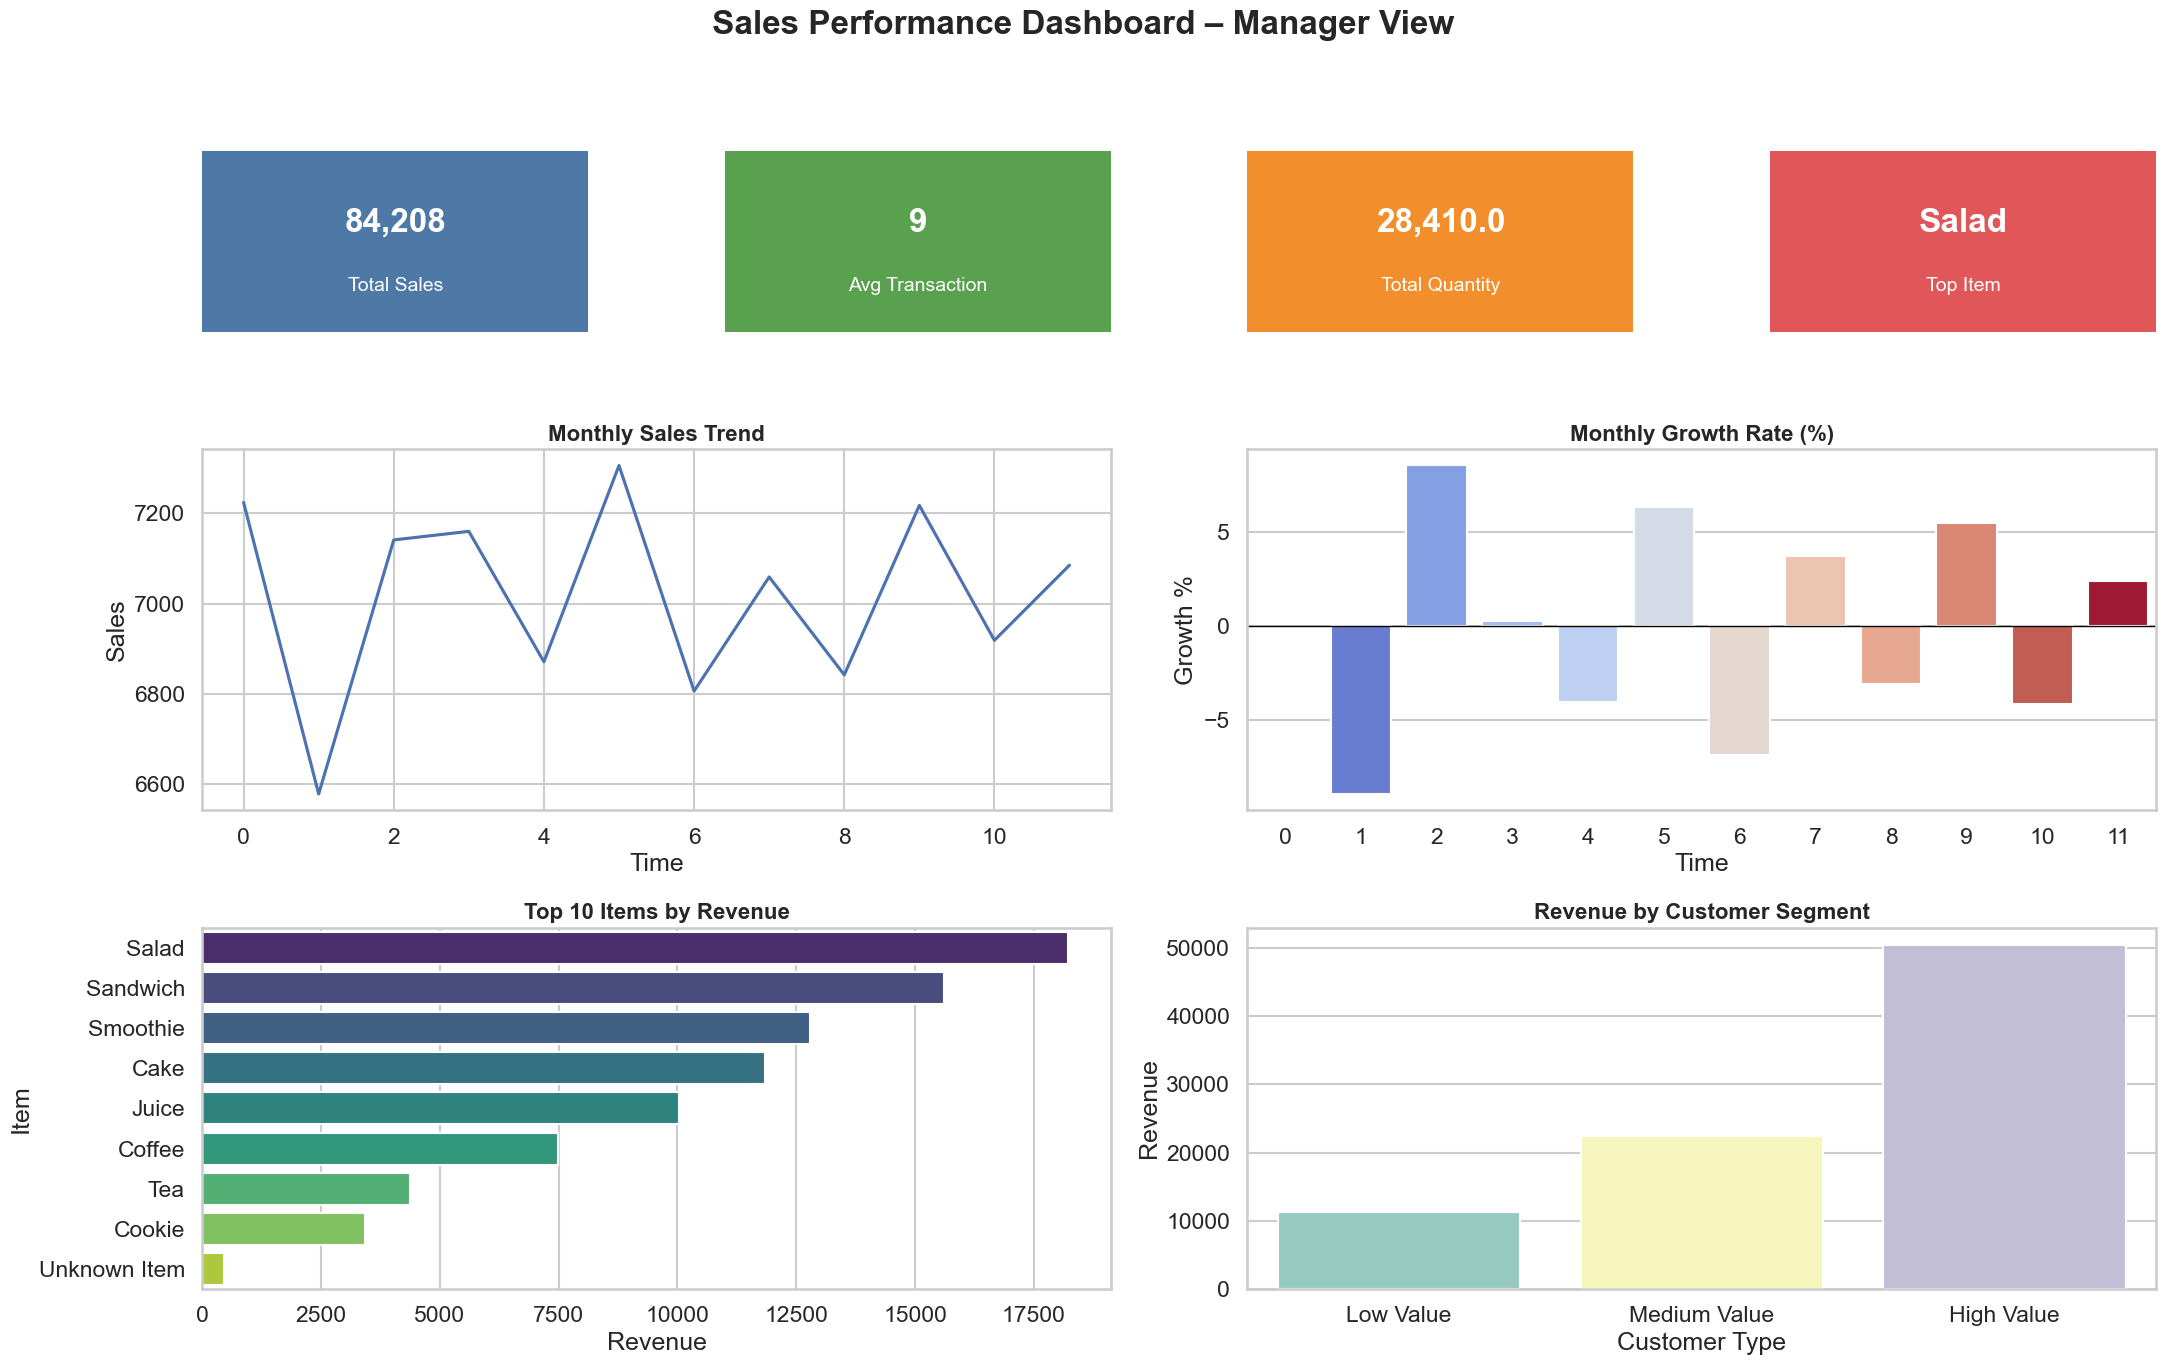

In [93]:
# =========================
# CLEAN SINGLE PAGE DASHBOARD (NO WARNINGS)
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

fig = plt.figure(figsize=(22, 14))
gs = plt.GridSpec(3, 4, height_ratios=[1, 2, 2])

# =========================
# KPI CARDS
# =========================
kpi_axes = [
    plt.subplot(gs[0, 0]),
    plt.subplot(gs[0, 1]),
    plt.subplot(gs[0, 2]),
    plt.subplot(gs[0, 3])
]

kpi_colors = ["#4E79A7", "#59A14F", "#F28E2B", "#E15759"]
kpi_titles = ["Total Sales", "Avg Transaction", "Total Quantity", "Top Item"]
kpi_values = [
    f"{total_sales:,.0f}",
    f"{avg_transaction:,.0f}",
    f"{total_quantity:,}",
    item_sales.iloc[0]["Item"]
]

for ax, color, title, value in zip(kpi_axes, kpi_colors, kpi_titles, kpi_values):
    ax.set_facecolor(color)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.text(0.5, 0.6, value, fontsize=24, color="white",
            ha="center", va="center", weight="bold", wrap=True)
    ax.text(0.5, 0.25, title, fontsize=14, color="white",
            ha="center", va="center")

# =========================
# MONTHLY SALES TREND
# =========================
ax5 = plt.subplot(gs[1, :2])
sns.lineplot(
    ax=ax5,
    data=monthly_sales,
    x=monthly_sales.index,
    y="Total Spent"
)
ax5.set_title("Monthly Sales Trend", fontsize=16, weight="bold")
ax5.set_xlabel("Time")
ax5.set_ylabel("Sales")

# =========================
# MONTHLY GROWTH RATE
# =========================
ax6 = plt.subplot(gs[1, 2:])
sns.barplot(
    ax=ax6,
    data=monthly_sales,
    x=monthly_sales.index,
    y="Growth_Rate_%",
    hue=monthly_sales.index,   # FIX
    palette="coolwarm",
    legend=False
)
ax6.axhline(0, color="black", linewidth=1)
ax6.set_title("Monthly Growth Rate (%)", fontsize=16, weight="bold")
ax6.set_xlabel("Time")
ax6.set_ylabel("Growth %")

# =========================
# TOP 10 ITEMS BY REVENUE
# =========================
ax7 = plt.subplot(gs[2, 0:2])
sns.barplot(
    ax=ax7,
    data=item_sales.head(10),
    x="Total Spent",
    y="Item",
    hue="Item",               # FIX
    palette="viridis",
    legend=False
)
ax7.set_title("Top 10 Items by Revenue", fontsize=16, weight="bold")
ax7.set_xlabel("Revenue")
ax7.set_ylabel("Item")

# =========================
# CUSTOMER SEGMENT REVENUE
# =========================
ax8 = plt.subplot(gs[2, 2:])

segment_revenue = (
    df.groupby("Customer_Type", observed=False)["Total Spent"]  # FIX
    .sum()
    .reset_index()
)

sns.barplot(
    ax=ax8,
    data=segment_revenue,
    x="Customer_Type",
    y="Total Spent",
    hue="Customer_Type",      # FIX
    palette="Set3",
    legend=False
)

ax8.set_title("Revenue by Customer Segment", fontsize=16, weight="bold")
ax8.set_xlabel("Customer Type")
ax8.set_ylabel("Revenue")

# =========================
# FINAL TITLE
# =========================
plt.suptitle(
    "Sales Performance Dashboard – Manager View",
    fontsize=24,
    weight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


In [ ]:
#✔ Business revenue is quantity-driven
#✔ Few products dominate overall sales
#✔ Digital payments show higher spending behavior
#✔ Seasonal demand significantly impacts sales
#✔ High-value transactions contribute major revenue share
#✔ Location performance varies by pricing and footfall